In [22]:
# load data here
#Enter answer here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import database
df= pd.read_csv('diabetes_dataset.csv')


# Droping invase variables
cols_to_drop = [
    'cholesterol_total', 
    'hdl_cholesterol', 'ldl_cholesterol',
    'triglycerides', 'glucose_fasting', 'glucose_postprandial',
    'insulin_level', 
    'hba1c', 'diabetes_risk_score', 
    'diabetes_stage'
]

Z= df.drop(columns=cols_to_drop, errors='ignore').copy()

Z.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'diagnosed_diabetes'],
      dtype='object')

In [23]:
cat_cols = Z.select_dtypes(include=['object', 'category']).columns
num_cols = Z.select_dtypes(include=['number']).columns


In [24]:
encoded = pd.get_dummies(Z[cat_cols], drop_first=True)


In [25]:
df_final = pd.concat([Z[num_cols], encoded], axis=1)


In [26]:
df_final.head()
df_final.columns


Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'diagnosed_diabetes', 'gender_Male',
       'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic',
       'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle',
       'income_level_Upper-Middle', 'employment_status_Retired',
       'employment_status_Student', 'employment_status_Unemployed',
       'smoking_status_Former', 'smoking_status_Never'],
      dtype='object')

In [27]:
corr = Z[num_cols].corr()
corr

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,diagnosed_diabetes
age,1.000000,0.000994,0.003352,-0.003326,-0.002802,-0.004704,-0.002877,0.177706,0.146797,0.092643,0.069654,0.547696,0.196996,-0.000597,0.137713
alcohol_consumption_per_week,0.000994,1.000000,-0.002185,-0.000265,0.001556,0.001004,0.002531,-0.007079,-0.004311,-0.001867,-0.003867,-0.005084,-0.000526,0.001976,0.000760
physical_activity_minutes_per_week,0.003352,-0.002185,1.000000,-0.002470,-0.004735,0.000996,-0.007021,-0.001176,0.000466,-0.071907,-0.053932,-0.008599,-0.008632,-0.253275,-0.100774
diet_score,-0.003326,-0.000265,-0.002470,1.000000,0.001255,0.002113,0.000336,0.001806,0.003828,-0.201303,-0.154968,-0.040278,-0.030300,0.000294,-0.044298
sleep_hours_per_day,-0.002802,0.001556,-0.004735,0.001255,1.000000,0.004732,0.003642,0.004753,-0.000437,0.000400,0.000788,-0.001312,-0.002214,0.010428,-0.000399
screen_time_hours_per_day,-0.004704,0.001004,0.000996,0.002113,0.004732,1.000000,-0.001641,-0.001567,-0.002255,-0.003019,-0.002765,-0.001859,-0.000021,-0.000515,0.018127
family_history_diabetes,-0.002877,0.002531,-0.007021,0.000336,0.003642,-0.001641,1.000000,0.003300,0.001188,0.000309,0.003107,-0.001036,0.002919,0.005585,0.197926
hypertension_history,0.177706,-0.007079,-0.001176,0.001806,0.004753,-0.001567,0.003300,1.000000,0.022182,0.014494,0.013719,0.098397,0.039952,0.000922,0.027524
cardiovascular_history,0.146797,-0.004311,0.000466,0.003828,-0.000437,-0.002255,0.001188,0.022182,1.000000,0.009956,0.005370,0.081879,0.026001,0.005019,0.029793
bmi,0.092643,-0.001867,-0.071907,-0.201303,0.000400,-0.003019,0.000309,0.014494,0.009956,1.000000,0.765744,0.245304,0.150501,0.015259,0.097057


In [28]:
threshold = 0.85

high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))   # upper triangle only
        .stack()                                                # convert to pairs
        .reset_index()                                          # nice tabular format
)

high_corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]

# Filter based on threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > threshold]

high_corr_pairs


,Variable_1,Variable_2,Correlation


In [29]:
num_cols

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'diagnosed_diabetes'],
      dtype='object')

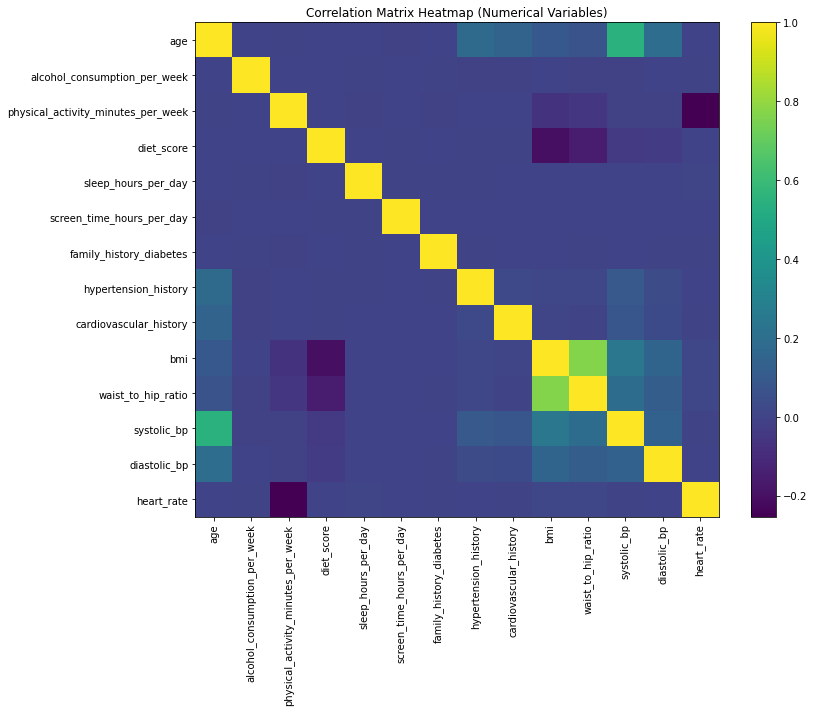

In [30]:
import matplotlib.pyplot as plt
import numpy as np
num_cols = [col for col in num_cols if col != 'diagnosed_diabetes'].copy()
# Compute correlation matrix
corr = Z[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns
)

plt.title("Correlation Matrix Heatmap (Numerical Variables)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=1200, bbox_inches="tight")
plt.show()

In [31]:
# Download correlaction matrix

# plt.savefig("correlation matrix.png", dpi=300, bbox_inches='tight')


In [32]:
print(df_final.shape)
df_final = df_final.dropna().reset_index(drop=True)
print(df_final.shape)

(100000, 33)
(100000, 33)


In [33]:
# df_final.to_csv("df_final.csv", index=False)

In [34]:
df_final.head(5)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,education_level_Postgraduate,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Former,smoking_status_Never
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,False,False,True,False,False,False,False,False,False,True
1,48,1,143,6.7,6.5,8.7,0,0,0,23.1,...,False,False,False,True,False,False,False,False,True,False
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,False,False,False,True,False,False,False,True,False,True
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,False,True,False,False,False,True,False,False,False,True
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,False,False,False,True,False,True,False,False,False,True


In [35]:
df_final.columns

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'diagnosed_diabetes', 'gender_Male',
       'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic',
       'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle',
       'income_level_Upper-Middle', 'employment_status_Retired',
       'employment_status_Student', 'employment_status_Unemployed',
       'smoking_status_Former', 'smoking_status_Never'],
      dtype='object')

In [36]:
df_final  ['diagnosed_diabetes']

0        1
1        0
2        1
3        1
4        1
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diagnosed_diabetes, Length: 100000, dtype: int64

In [37]:
y=df_final['diagnosed_diabetes']

In [38]:
X= df_final.drop(columns=['diagnosed_diabetes']).copy()
X.shape

(100000, 32)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # no stratify
)
# X_train.info()

In [40]:
# df_final.columns

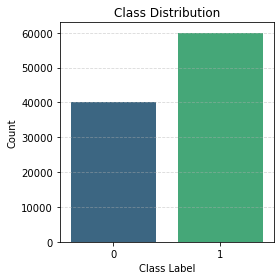

In [41]:
plt.figure(figsize=(4,4))
sns.countplot(
    x='diagnosed_diabetes',
    hue='diagnosed_diabetes',          # 🔹 assign hue to use palette safely
    data=df_final,
    palette='viridis',
    legend=False                # 🔹 hide duplicate legend
)

plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors


def random_oversample(X, y, sampling_strategy='auto', random_state=None):
    """
    Random oversampling - duplicates minority class samples
    
    Parameters:
    -----------
    X : array-like or DataFrame
        Features
    y : array-like or Series
        Target variable
    sampling_strategy : float or 'auto'
        If 'auto', balance classes. If float, ratio of minority to majority
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    X_resampled, y_resampled : resampled data
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Convert to arrays if needed
    is_dataframe = isinstance(X, pd.DataFrame)
    if is_dataframe:
        X_df = X.copy()
        X = X.values
        y_name = y.name if hasattr(y, 'name') else 'target'
        y = y.values
    else:
        X = np.array(X)
        y = np.array(y)
    
    # Get class information
    classes, counts = np.unique(y, return_counts=True)
    majority_class = classes[counts.argmax()]
    minority_class = classes[counts.argmin()]
    majority_count = counts.max()
    minority_count = counts.min()
    
    # Determine target count for minority class
    if sampling_strategy == 'auto':
        target_count = majority_count
    else:
        target_count = int(majority_count * sampling_strategy)
    
    # Get indices
    minority_indices = np.where(y == minority_class)[0]
    majority_indices = np.where(y == majority_class)[0]
    
    # Oversample minority class
    n_samples_needed = target_count - minority_count
    oversample_indices = np.random.choice(
        minority_indices, 
        size=n_samples_needed, 
        replace=True
    )
    
    # Combine all indices
    all_indices = np.concatenate([
        np.arange(len(y)),  # All original samples
        oversample_indices   # Additional minority samples
    ])
    
    X_resampled = X[all_indices]
    y_resampled = y[all_indices]
    
    # Convert back to DataFrame if needed
    if is_dataframe:
        X_resampled = pd.DataFrame(X_resampled, columns=X_df.columns)
        y_resampled = pd.Series(y_resampled, name=y_name)
    
    return X_resampled, y_resampled


def random_undersample(X, y, sampling_strategy='auto', random_state=None):
    """
    Random undersampling - removes majority class samples
    
    Parameters:
    -----------
    X : array-like or DataFrame
        Features
    y : array-like or Series
        Target variable
    sampling_strategy : float or 'auto'
        If 'auto', balance classes. If float, ratio of majority to minority
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    X_resampled, y_resampled : resampled data
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Convert to arrays if needed
    is_dataframe = isinstance(X, pd.DataFrame)
    if is_dataframe:
        X_df = X.copy()
        X = X.values
        y_name = y.name if hasattr(y, 'name') else 'target'
        y = y.values
    else:
        X = np.array(X)
        y = np.array(y)
    
    # Get class information
    classes, counts = np.unique(y, return_counts=True)
    majority_class = classes[counts.argmax()]
    minority_class = classes[counts.argmin()]
    minority_count = counts.min()
    
    # Determine target count for majority class
    if sampling_strategy == 'auto':
        target_count = minority_count
    else:
        target_count = int(minority_count / sampling_strategy)
    
    # Get indices
    minority_indices = np.where(y == minority_class)[0]
    majority_indices = np.where(y == majority_class)[0]
    
    # Undersample majority class
    majority_indices_sampled = np.random.choice(
        majority_indices,
        size=target_count,
        replace=False
    )
    
    # Combine indices
    all_indices = np.concatenate([minority_indices, majority_indices_sampled])
    np.random.shuffle(all_indices)
    
    X_resampled = X[all_indices]
    y_resampled = y[all_indices]
    
    # Convert back to DataFrame if needed
    if is_dataframe:
        X_resampled = pd.DataFrame(X_resampled, columns=X_df.columns)
        y_resampled = pd.Series(y_resampled, name=y_name)
    
    return X_resampled, y_resampled


def smote(X, y, k_neighbors=5, sampling_strategy='auto', random_state=None):
    """
    SMOTE (Synthetic Minority Over-sampling Technique)
    Creates synthetic samples by interpolating between minority class neighbors
    
    Parameters:
    -----------
    X : array-like or DataFrame
        Features
    y : array-like or Series
        Target variable
    k_neighbors : int
        Number of nearest neighbors to use
    sampling_strategy : float or 'auto'
        If 'auto', balance classes. If float, ratio of minority to majority
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    X_resampled, y_resampled : resampled data
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Convert to arrays if needed
    is_dataframe = isinstance(X, pd.DataFrame)
    if is_dataframe:
        X_df = X.copy()
        X = X.values
        y_name = y.name if hasattr(y, 'name') else 'target'
        y = y.values
    else:
        X = np.array(X)
        y = np.array(y)
    
    # Get class information
    classes, counts = np.unique(y, return_counts=True)
    majority_class = classes[counts.argmax()]
    minority_class = classes[counts.argmin()]
    majority_count = counts.max()
    minority_count = counts.min()
    
    # Determine how many synthetic samples to create
    if sampling_strategy == 'auto':
        n_synthetic = majority_count - minority_count
    else:
        n_synthetic = int(majority_count * sampling_strategy) - minority_count
    
    # Get minority class samples
    minority_indices = np.where(y == minority_class)[0]
    X_minority = X[minority_indices]
    
    # Fit nearest neighbors
    nn = NearestNeighbors(n_neighbors=min(k_neighbors + 1, len(X_minority)))
    nn.fit(X_minority)
    
    # Generate synthetic samples
    synthetic_samples = []
    for _ in range(n_synthetic):
        # Pick a random minority sample
        idx = np.random.randint(0, len(X_minority))
        sample = X_minority[idx]
        
        # Find its k nearest neighbors
        neighbors_indices = nn.kneighbors([sample], return_distance=False)[0][1:]
        
        # Pick a random neighbor
        neighbor_idx = np.random.choice(neighbors_indices)
        neighbor = X_minority[neighbor_idx]
        
        # Create synthetic sample (interpolation)
        gap = np.random.random()
        synthetic = sample + gap * (neighbor - sample)
        synthetic_samples.append(synthetic)
    
    # Combine original and synthetic samples
    X_resampled = np.vstack([X, synthetic_samples])
    y_resampled = np.hstack([y, [minority_class] * len(synthetic_samples)])
    
    # Convert back to DataFrame if needed
    if is_dataframe:
        X_resampled = pd.DataFrame(X_resampled, columns=X_df.columns)
        y_resampled = pd.Series(y_resampled, name=y_name)
    
    return X_resampled, y_resampled

In [43]:
# # Random Oversampling (duplicates minority samples)
# X_resampled_ro, y_resampled_ro = random_oversample(X_train, y_train, random_state=42)

# # Random Undersampling (removes majority samples)
# X_resampled_ru, y_resampled_ru = random_undersample(X_train, y_train, random_state=42)

# SMOTE (creates synthetic minority samples)
X_resampled_sm, y_resampled_sm = smote(X_train, y_train, k_neighbors=5, random_state=42)

Training GridSearch with Feature Selection for Imbalanced Data...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

BEST PARAMETERS: {'classifier__C': 10, 'classifier__max_iter': 5000, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear', 'feature_selection__k': 8}
BEST CV F1 SCORE: 0.8628

TEST SET EVALUATION
Accuracy:  0.8322
F1 Score:  0.8615
Precision: 0.8478
Recall:    0.8757
ROC-AUC:   0.9095

CONFUSION MATRIX HEATMAP


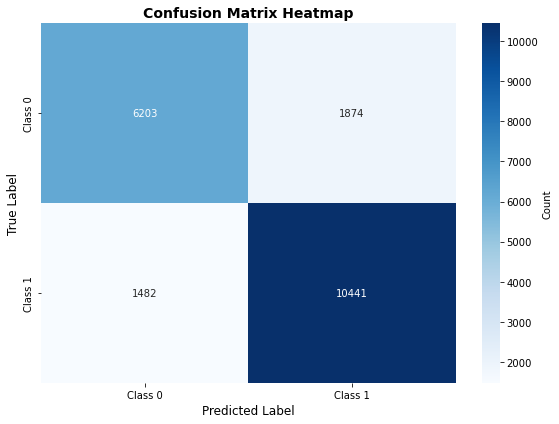


Interpretation:
True Negatives  (TN): 6203
False Positives (FP): 1874
False Negatives (FN): 1482
True Positives  (TP): 10441

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      8077
           1       0.85      0.88      0.86     11923

    accuracy                           0.83     20000
   macro avg       0.83      0.82      0.82     20000
weighted avg       0.83      0.83      0.83     20000


TOP 5 PARAMETER COMBINATIONS

Rank 1:
  Parameters: {'classifier__C': 10, 'classifier__max_iter': 5000, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear', 'feature_selection__k': 8}
  CV F1 Score: 0.8628 (+/- 0.0024)

SELECTED FEATURES
Number of features selected: 8
Selected feature indices: [ 0  2  6  9 10 11 17 18]
Selected feature names: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'glucose_fasting', 'glucose_postprandial']


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, f1_score, precision_score, 
                              recall_score, roc_auc_score)

# ============================================================================
# GRIDSEARCH FOR IMBALANCED DATA WITH FEATURE SELECTION
# ============================================================================

# Create pipeline with feature selection
pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif)),
    ('classifier', LogisticRegression(random_state=42))
])

# Comprehensive parameter grid with feature selection
param_grid = [
    # L1 regularization with feature selection
    # {
    #     'feature_selection__k': [6],  # Number of features to select
    #     'classifier__penalty': ['l1'],
    #     'classifier__solver': ['liblinear'],
    #     'classifier__C': [10],
    #     # 'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}],
    #     'classifier__max_iter': [5000]
    # },
    # L2 regularization with feature selection
    {
        'feature_selection__k': [8],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['liblinear'],
        'classifier__C': [10],
        # 'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}],
        'classifier__max_iter': [5000]
     }                     ,
    # ElasticNet regularization with feature selection
    # {
    #     'feature_selection__k': [6],
    #     'classifier__penalty': ['elasticnet'],
    #     'classifier__solver': ['saga'],
    #     'classifier__C': [ 0.1, 1],
    #     'classifier__l1_ratio': [0.3,0.7],
    #    # 'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}],
    #     'classifier__max_iter': [5000]
    # },
    # # No regularization with feature selection
    # {
    #     'feature_selection__k': ['all', 10, 20, 30, 50],
    #     'classifier__penalty': [None],
    #     'classifier__solver': ['saga'],
    #     'classifier__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}],
    #     'classifier__max_iter': [1000, 2000]
    # }
]

# GridSearch with F1 score
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit
print("Training GridSearch with Feature Selection for Imbalanced Data...")
grid_search.fit(X_train, y_train)

# Results
print("\n" + "="*60)
print("BEST PARAMETERS:", grid_search.best_params_)
print("BEST CV F1 SCORE:", f"{grid_search.best_score_:.4f}")
print("="*60)

# Get best model
best_model = grid_search.best_estimator_

# Predictions on test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX HEATMAP")
print("="*60)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"True Negatives  (TN): {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives  (TP): {cm[1,1]}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))

# Optional: View top 5 parameter combinations
print("\n" + "="*60)
print("TOP 5 PARAMETER COMBINATIONS")
print("="*60)
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

for idx, row in results_df.head(5).iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Parameters: {row['params']}")
    print(f"  CV F1 Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")

# Show selected features if using feature selection
print("\n" + "="*60)
print("SELECTED FEATURES")
print("="*60)
if 'feature_selection' in best_model.named_steps:
    k_features = best_model.named_steps['feature_selection'].k
    if k_features != 'all':
        selected_features = best_model.named_steps['feature_selection'].get_support(indices=True)
        print(f"Number of features selected: {len(selected_features)}")
        print(f"Selected feature indices: {selected_features}")
        
        # If X_train is a DataFrame, show feature names
        if hasattr(X_train, 'columns'):
            feature_names = X_train.columns[selected_features].tolist()
            print(f"Selected feature names: {feature_names}")
    else:
        print("All features were selected")
else:
    print("No feature selection was applied")

TRAINING LOGISTIC REGRESSION WITH CROSS-VALIDATION
Number of features: 6
Selected features: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'glucose_fasting', 'glucose_postprandial']

Performing 5-fold cross-validation on training data...
------------------------------------------------------------

CROSS-VALIDATION RESULTS (5-FOLD)
   Metric     Mean      Std      Min      Max
 Accuracy 0.842288 0.001568 0.840500 0.844500
Precision 0.893229 0.001165 0.891516 0.894849
   Recall 0.837691 0.003181 0.832865 0.841706
 F1 Score 0.864565 0.001577 0.862745 0.866767
  ROC-AUC 0.912268 0.001604 0.909907 0.914845


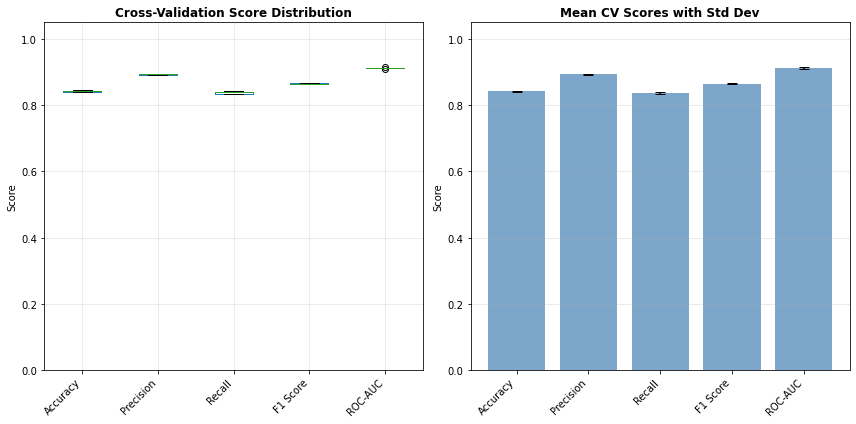


FOLD-BY-FOLD RESULTS
 Fold  Accuracy  Precision   Recall       F1  ROC-AUC
    1  0.843625   0.893985 0.839314 0.865787 0.912171
    2  0.840750   0.894849 0.832865 0.862745 0.909907
    3  0.844500   0.893366 0.841706 0.866767 0.914845
    4  0.840500   0.892432 0.835257 0.862899 0.911651
    5  0.842063   0.891516 0.839314 0.864627 0.912768

TRAINING FINAL MODEL ON FULL TRAINING DATA
Final model trained successfully!

MODEL COEFFICIENTS
                           Feature  Coefficient
           family_history_diabetes     0.324544
              glucose_postprandial     0.068770
                   glucose_fasting     0.060278
                               bmi     0.019628
                               age     0.006101
physical_activity_minutes_per_week    -0.000858


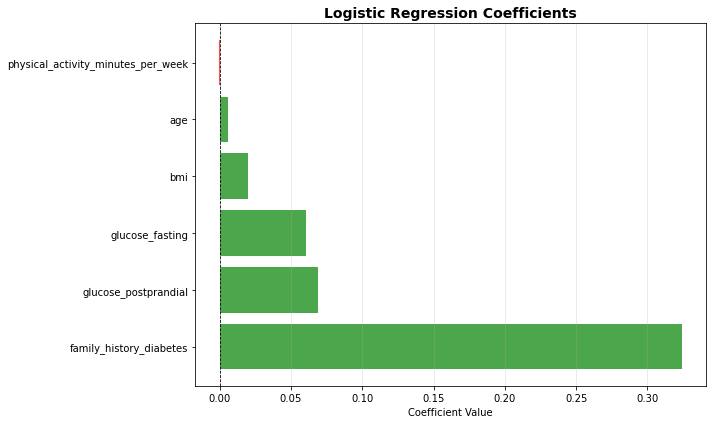


TEST SET EVALUATION
Accuracy:  0.8436
F1 Score:  0.8638
Precision: 0.8978
Recall:    0.8323
ROC-AUC:   0.9108

CONFUSION MATRIX


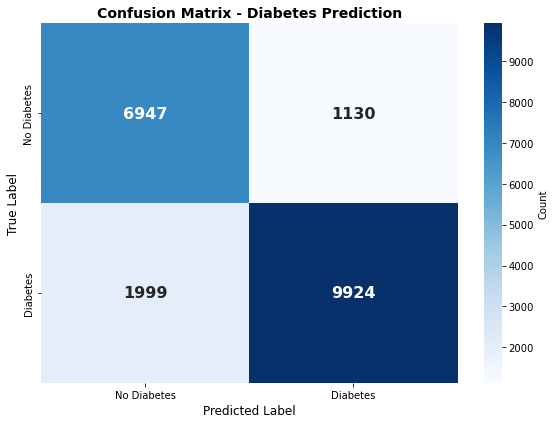


Confusion Matrix Values:
True Negatives  (TN): 6947 - Correctly predicted No Diabetes
False Positives (FP): 1130 - Incorrectly predicted Diabetes
False Negatives (FN): 1999 - Missed Diabetes cases
True Positives  (TP): 9924 - Correctly predicted Diabetes

ADDITIONAL METRICS
Sensitivity (Recall):     0.8323 - 83.23% of diabetes cases detected
Specificity:              0.8601 - 86.01% of non-diabetes correctly identified
Positive Predictive Value: 0.8978 - 89.78% accuracy when predicting diabetes
Negative Predictive Value: 0.7765 - 77.65% accuracy when predicting no diabetes

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes       0.78      0.86      0.82      8077
    Diabetes       0.90      0.83      0.86     11923

    accuracy                           0.84     20000
   macro avg       0.84      0.85      0.84     20000
weighted avg       0.85      0.84      0.84     20000


PREDICTION PROBABILITY DISTRIBUTION


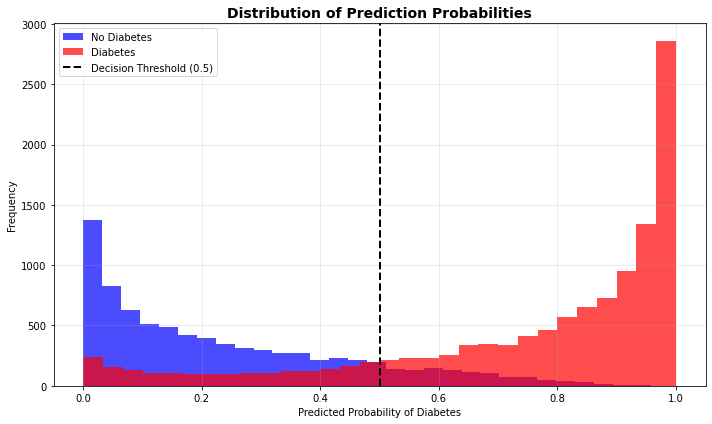

Probability statistics:
  Mean probability (No Diabetes class): 0.2370
  Mean probability (Diabetes class):    0.7574

MODEL SUMMARY
Model: Logistic Regression
Features used: 6
Training samples: 80000
Test samples: 20000
Best performance metric (F1): 0.8638

To use this model on new data:
  new_predictions = log_reg.predict(new_data[selected_feature_names])


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, f1_score, precision_score, 
                              recall_score, roc_auc_score, make_scorer)

# ============================================================================
# TRAIN LOGISTIC REGRESSION WITH CROSS-VALIDATION
# ============================================================================

# Selected features
selected_features = [0, 2, 6, 9, 17, 18]
selected_feature_names = ['age', 'physical_activity_minutes_per_week', 
                          'family_history_diabetes', 'bmi', 
                          'glucose_fasting', 'glucose_postprandial']

print("="*60)
print("TRAINING LOGISTIC REGRESSION WITH CROSS-VALIDATION")
print("="*60)
print(f"Number of features: {len(selected_features)}")
print(f"Selected features: {selected_feature_names}")
print()

# Select only the specified features from training and test data
X_train_selected = X_train.iloc[:, selected_features]
X_test_selected = X_test.iloc[:, selected_features]

# Create the logistic regression model
log_reg = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# ============================================================================
# CROSS-VALIDATION ON TRAINING DATA
# ============================================================================

print("Performing 5-fold cross-validation on training data...")
print("-" * 60)

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc'
}

# Perform cross-validation
cv_results = cross_validate(
    log_reg, 
    X_train_selected, 
    y_train, 
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Display cross-validation results
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*60)

cv_metrics = {
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1 Score': cv_results['test_f1'],
    'ROC-AUC': cv_results['test_roc_auc']
}

cv_summary = pd.DataFrame({
    'Metric': cv_metrics.keys(),
    'Mean': [np.mean(scores) for scores in cv_metrics.values()],
    'Std': [np.std(scores) for scores in cv_metrics.values()],
    'Min': [np.min(scores) for scores in cv_metrics.values()],
    'Max': [np.max(scores) for scores in cv_metrics.values()]
})

print(cv_summary.to_string(index=False))

# Visualize cross-validation results
plt.figure(figsize=(12, 6))

# Box plot of CV scores
plt.subplot(1, 2, 1)
cv_data = pd.DataFrame(cv_metrics)
cv_data.boxplot()
plt.title('Cross-Validation Score Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.05])

# Bar plot with error bars
plt.subplot(1, 2, 2)
means = [np.mean(scores) for scores in cv_metrics.values()]
stds = [np.std(scores) for scores in cv_metrics.values()]
x_pos = np.arange(len(cv_metrics))
plt.bar(x_pos, means, yerr=stds, alpha=0.7, capsize=5, color='steelblue')
plt.xticks(x_pos, cv_metrics.keys(), rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Mean CV Scores with Std Dev', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Display fold-by-fold results
print("\n" + "="*60)
print("FOLD-BY-FOLD RESULTS")
print("="*60)
fold_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1': cv_results['test_f1'],
    'ROC-AUC': cv_results['test_roc_auc']
})
print(fold_results.to_string(index=False))

# ============================================================================
# TRAIN FINAL MODEL ON FULL TRAINING DATA
# ============================================================================

print("\n" + "="*60)
print("TRAINING FINAL MODEL ON FULL TRAINING DATA")
print("="*60)

log_reg.fit(X_train_selected, y_train)
print("Final model trained successfully!")

# ============================================================================
# MODEL COEFFICIENTS
# ============================================================================

print("\n" + "="*60)
print("MODEL COEFFICIENTS")
print("="*60)

coefficients = pd.DataFrame({
    'Feature': selected_feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coefficients.to_string(index=False))

# Plot coefficients
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ============================================================================
# PREDICTIONS
# ============================================================================

# Predictions on test set
y_pred = log_reg.predict(X_test_selected)
y_pred_proba = log_reg.predict_proba(X_test_selected)[:, 1]

# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

# ============================================================================
# CONFUSION MATRIX HEATMAP
# ============================================================================

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - Diabetes Prediction', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Values:")
print(f"True Negatives  (TN): {cm[0,0]:4d} - Correctly predicted No Diabetes")
print(f"False Positives (FP): {cm[0,1]:4d} - Incorrectly predicted Diabetes")
print(f"False Negatives (FN): {cm[1,0]:4d} - Missed Diabetes cases")
print(f"True Positives  (TP): {cm[1,1]:4d} - Correctly predicted Diabetes")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

print("\n" + "="*60)
print("ADDITIONAL METRICS")
print("="*60)
print(f"Sensitivity (Recall):     {sensitivity:.4f} - {sensitivity*100:.2f}% of diabetes cases detected")
print(f"Specificity:              {specificity:.4f} - {specificity*100:.2f}% of non-diabetes correctly identified")
print(f"Positive Predictive Value: {ppv:.4f} - {ppv*100:.2f}% accuracy when predicting diabetes")
print(f"Negative Predictive Value: {npv:.4f} - {npv*100:.2f}% accuracy when predicting no diabetes")

# ============================================================================
# CLASSIFICATION REPORT
# ============================================================================

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# ============================================================================
# PREDICTION PROBABILITIES DISTRIBUTION
# ============================================================================

print("\n" + "="*60)
print("PREDICTION PROBABILITY DISTRIBUTION")
print("="*60)

plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, label='No Diabetes', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Diabetes', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
plt.xlabel('Predicted Probability of Diabetes')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Probabilities', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Probability statistics:")
print(f"  Mean probability (No Diabetes class): {y_pred_proba[y_test == 0].mean():.4f}")
print(f"  Mean probability (Diabetes class):    {y_pred_proba[y_test == 1].mean():.4f}")

# ============================================================================
# SAVE MODEL (optional)
# ============================================================================

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Model: Logistic Regression")
print(f"Features used: {len(selected_feature_names)}")
print(f"Training samples: {len(X_train_selected)}")
print(f"Test samples: {len(X_test_selected)}")
print(f"Best performance metric (F1): {test_f1:.4f}")
print("\nTo use this model on new data:")
print("  new_predictions = log_reg.predict(new_data[selected_feature_names])")
print("="*60)